In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F 
from torch import optim
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pyvirtualdisplay import Display
from IPython import display as ipythondisplay
from IPython.display import clear_output
from pathlib import Path

import random, os.path, math, glob, csv, base64, itertools, sys
import gym
from gym.wrappers.record_video import RecordVideo
from pprint import pprint

# The following code is will be used to visualize the environments.

In [50]:
class Model(nn.Module):
    def __init__(self, dim_observation, n_actions):
        super(Model, self).__init__()

        self.n_actions = n_actions
        self.dim_observation = dim_observation

        self.net = nn.Sequential(
            nn.Linear(self.dim_observation, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, self.n_actions)
        )

        self.saved_log_probs = []
        self.rewards = []

    def forward(self, state):
        return self.net(state)

    def select_action(self, state):
        if not isinstance(state, torch.Tensor):
            state = torch.tensor(state, dtype=torch.float32)

        logits = self.forward(state)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()

        self.saved_log_probs.append(dist.log_prob(action))

        return action.item()

In [51]:

env = gym.make("ma_gym:Combat-v0")

In [52]:
obs_n = env.reset()
done_n = [False for _ in range(env.n_agents)]

while not all(done_n):
    action_n = [env.action_space[i].sample() for i in range(env.n_agents)]
    obs_n, reward_n, done_n, info = env.step(action_n)
env.close()

### Message


In [53]:
from queue import Queue, Empty
from typing import Any, Dict, List
import time
import numpy as np


class Message:
    def __init__(self, sender: str, receiver: str, msg_type: str, content: Any = None):
        self.sender = sender
        self.receiver = receiver
        self.msg_type = msg_type
        self.content = content
        self.timestamp = time.time()
        self.status = "new"

    def __repr__(self):
        return (
            f"Message(from={self.sender}, to={self.receiver}, "
            f"type={self.msg_type}, content={self.content})"
        )


class MessageBroker:
    def __init__(self):
        self.queues: Dict[str, Queue] = {}

    def register_agent(self, agent_id: str):
        if agent_id not in self.queues:
            self.queues[agent_id] = Queue()

    def reset(self):
        for agent_id in self.queues:
            self.queues[agent_id] = Queue()

    def send_message(self, message: Message):
        if message.receiver in self.queues:
            self.queues[message.receiver].put(message)
        else:
            raise ValueError(f"Receiver not found: {message.receiver}")

    def get_all_messages(self, agent_id: str) -> List[Message]:
        if agent_id not in self.queues:
            raise ValueError(f"Agent not found: {agent_id}")

        messages = []
        while True:
            try:
                msg = self.queues[agent_id].get_nowait()
                messages.append(msg)
            except Empty:
                break
        return messages

In [54]:
MSG_DIM = 8

def encode_messages(messages):
    vec = np.zeros(MSG_DIM, dtype=np.float32)

    if len(messages) == 0:
        return vec

    info_msgs = [
        m for m in messages
        if m.msg_type == "info" and isinstance(m.content, dict)
    ]

    if len(info_msgs) == 0:
        return vec

    obs_sums = []
    obs_means = []
    ally_counts = []
    enemy_counts = []
    health_means = []

    for msg in info_msgs:
        content = msg.content

        obs_sums.append(content.get("obs_sum", 0.0))
        obs_means.append(content.get("obs_mean", 0.0))
        ally_counts.append(content.get("ally_count", 0.0))
        enemy_counts.append(content.get("enemy_count", 0.0))
        health_means.append(content.get("health_mean", 0.0))

    vec[0] = min(len(messages), 10) / 10.0
    vec[1] = min(len(info_msgs), 10) / 10.0

    vec[2] = np.mean(obs_sums) / 150.0
    vec[3] = np.mean(obs_means)
    vec[4] = np.mean(ally_counts) / 10.0
    vec[5] = np.mean(enemy_counts) / 10.0
    vec[6] = np.mean(health_means) / 3.0
    vec[7] = max(enemy_counts) / 10.0

    return vec

In [55]:
def augment_obs_with_messages(obs_n, broker: MessageBroker, agent_ids: List[str]):
    aug_obs_n = []

    for i, agent_id in enumerate(agent_ids):
        inbox = broker.get_all_messages(agent_id)
        msg_vec = encode_messages(inbox)
        aug_obs = np.concatenate([
            np.asarray(obs_n[i], dtype=np.float32),
            msg_vec
        ]).astype(np.float32)
        aug_obs_n.append(aug_obs)

    return np.array(aug_obs_n, dtype=np.float32)

In [56]:
def extract_message_content_from_obs(obs):
    obs = np.array(obs, dtype=np.float32)

    positive_values = obs[obs > 0]

    return {
        "obs_sum": float(np.sum(obs)),
        "obs_mean": float(np.mean(obs)),
        "ally_count": float(np.sum(obs == 1.0)),
        "enemy_count": float(np.sum(obs == 3.0)),
        "health_mean": float(np.mean(positive_values)) if len(positive_values) > 0 else 0.0,
    }

In [57]:
def compute_message_reward(sent_messages_count,
                           useful_messages_count,
                           invalid_messages_count,
                           spam_threshold=1):
    reward = 0.0

    # Message явуулахыг шууд шагнахгүй
    reward += 0.005 * useful_messages_count

    # Message cost
    reward -= 0.01 * sent_messages_count

    # Invalid message penalty
    reward -= 0.03 * invalid_messages_count

    # Spam penalty
    if sent_messages_count > spam_threshold:
        reward -= 0.02 * (sent_messages_count - spam_threshold)

    return reward

### A2C


In [58]:
import torch
import torch.nn as nn
import torch.optim as optim


class SharedActorNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class SharedValueNetwork(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [59]:
import numpy as np
import torch
import imageio.v2 as imageio


class MessageSharedA2CAgent:
    def __init__(self, env, gamma=0.99, lr_actor=1e-3, lr_critic=1e-3, entropy_coef=0.01):
        self.env = env
        self.gamma = gamma
        self.entropy_coef = entropy_coef

        self.n_agents = env.n_agents
        self.agent_ids = [f"agent{i}" for i in range(self.n_agents)]

        self.broker = MessageBroker()
        for agent_id in self.agent_ids:
            self.broker.register_agent(agent_id)

        self.base_obs_dim = env.observation_space[0].shape[0]
        self.obs_dim = self.base_obs_dim + MSG_DIM
        self.env_n_actions = env.action_space[0].n
        self.n_actions = self.env_n_actions + 1   # last action = send_message
        self.send_msg_action = self.env_n_actions

        self.actor_network = SharedActorNetwork(self.obs_dim, self.n_actions)
        self.critic_network = SharedValueNetwork(self.obs_dim)

        self.actor_optimizer = optim.Adam(self.actor_network.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic_network.parameters(), lr=lr_critic)

    def _returns_advantages(self, rewards, values, dones):
        returns = []
        R = np.zeros(self.n_agents, dtype=np.float32)

        for t in reversed(range(len(rewards))):
            R = rewards[t] + self.gamma * R * (1.0 - dones[t].astype(np.float32))
            returns.insert(0, R.copy())

        returns = np.array(returns, dtype=np.float32)
        values = np.array(values, dtype=np.float32)
        advantages = returns - values
        return returns, advantages

    def train_episode(self, max_steps=300):
        out = self.env.reset()
        obs_n = out[0] if isinstance(out, tuple) else out
        obs_n = np.asarray(obs_n, dtype=np.float32)

        self.broker.reset()

        obs_buffer = []
        log_probs_buffer = []
        values_buffer = []
        rewards_buffer = []
        dones_buffer = []
        entropies_buffer = []

        total_env_reward = np.zeros(self.n_agents, dtype=np.float32)
        total_msg_reward = np.zeros(self.n_agents, dtype=np.float32)

        for step in range(max_steps):
            # 1) одоогийн inbox-ийг obs дээр нэмэх
            aug_obs_n = augment_obs_with_messages(obs_n, self.broker, self.agent_ids)
            obs_tensor = torch.tensor(aug_obs_n, dtype=torch.float32)

            logits = self.actor_network(obs_tensor)
            dist = torch.distributions.Categorical(logits=logits)
            raw_actions = dist.sample()

            log_probs = dist.log_prob(raw_actions)
            entropies = dist.entropy()
            values = self.critic_network(obs_tensor).squeeze(-1)

            # rollout buffer
            obs_buffer.append(obs_tensor)
            log_probs_buffer.append(log_probs)
            values_buffer.append(values)

            # 2) agent бүр teammate руу message явуулна
            sent_counts = np.zeros(self.n_agents, dtype=np.float32)
            useful_counts = np.zeros(self.n_agents, dtype=np.float32)
            invalid_counts = np.zeros(self.n_agents, dtype=np.float32)
            
            raw_actions_np = raw_actions.cpu().numpy()

            env_actions = []
            send_flags = []

            for i in range(self.n_agents):
                a = int(raw_actions_np[i])

                if a == self.send_msg_action:
                    send_flags.append(True)

                    # message action сонгосон үед env дээр no-op/stay action өгнө
                    env_actions.append(0)
                else:
                    send_flags.append(False)
                    env_actions.append(a)
            
            for i  in range(self.n_agents):
                if not send_flags[i]:
                    continue

                content = extract_message_content_from_obs(obs_n[i])

                is_useful = int(
                    isinstance(content, dict) and
                    "obs_sum" in content and
                    "obs_mean" in content and
                    "ally_count" in content and
                    "enemy_count" in content and
                    "health_mean" in content
                )

                if is_useful:
                    for j in range(self.n_agents):
                        if i != j:
                            self.broker.send_message(
                                Message(
                                    sender=self.agent_ids[i],
                                    receiver=self.agent_ids[j],
                                    msg_type="info",
                                    content=content
                                )
                            )

                    sent_counts[i] += self.n_agents - 1
                    useful_counts[i] += 1
                else:
                    invalid_counts[i] += 1

            # 3) env step
            step_out = self.env.step(env_actions)

            if len(step_out) == 5:
                next_obs_n, reward_n, terminated_n, truncated_n, info = step_out
                done_n = np.logical_or(terminated_n, truncated_n)
            else:
                next_obs_n, reward_n, done_n, info = step_out

            next_obs_n = np.asarray(next_obs_n, dtype=np.float32)
            reward_n = np.asarray(reward_n, dtype=np.float32)
            done_n = np.asarray(done_n, dtype=bool)

            # 4) message reward shaping
            msg_reward_n = np.zeros(self.n_agents, dtype=np.float32)
            for i in range(self.n_agents):
                msg_reward_n[i] = compute_message_reward(
                    sent_messages_count=int(sent_counts[i]),
                    useful_messages_count=int(useful_counts[i]),
                    invalid_messages_count=int(invalid_counts[i]),
                )

            final_reward_n = reward_n

            rewards_buffer.append(final_reward_n)
            dones_buffer.append(done_n)
            entropies_buffer.append(entropies)

            total_env_reward += reward_n
            total_msg_reward += msg_reward_n

            obs_n = np.asarray(next_obs_n, dtype=np.float32)

            if np.all(done_n):
                break

        returns, advantages = self._returns_advantages(
            rewards_buffer,
            [v.detach().cpu().numpy() for v in values_buffer],
            dones_buffer
        )

        returns_t = torch.tensor(returns, dtype=torch.float32)

        log_probs_t = torch.stack(log_probs_buffer)
        values_t = torch.stack(values_buffer)
        entropies_t = torch.stack(entropies_buffer)
        advantages_t = returns_t - values_t
        norm_advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)

        actor_loss = -(log_probs_t * norm_advantages_t.detach()).mean()
        critic_loss = ((values_t - returns_t) ** 2).mean()
        entropy_bonus = entropies_t.mean()

        loss = actor_loss + 0.5 * critic_loss - self.entropy_coef * entropy_bonus

        self.actor_optimizer.zero_grad()
        self.critic_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor_network.parameters(), 0.5)
        torch.nn.utils.clip_grad_norm_(self.critic_network.parameters(), 0.5)
        self.actor_optimizer.step()
        self.critic_optimizer.step()

        return {
            "team_env_reward": float(np.sum(total_env_reward)),
            "team_msg_reward": float(np.sum(total_msg_reward)),
            "team_total_reward": float(np.sum(total_env_reward + total_msg_reward)),
            "actor_loss": float(actor_loss.item()),
            "critic_loss": float(critic_loss.item())
        }
    
    def save(self, path="message_a2c_combat.pth"):
        checkpoint = {
            "actor_state_dict": self.actor_network.state_dict(),
            "critic_state_dict": self.critic_network.state_dict(),
            "actor_optimizer_state_dict": self.actor_optimizer.state_dict(),
            "critic_optimizer_state_dict": self.critic_optimizer.state_dict(),
            "base_obs_dim": self.base_obs_dim,
            "obs_dim": self.obs_dim,
            "n_actions": self.n_actions,
            "n_agents": self.n_agents,
            "gamma": self.gamma,
            "entropy_coef": self.entropy_coef
        }
        torch.save(checkpoint, path)
        print(f"Model saved to {path}")


    def load(self, path="message_a2c_combat.pth", load_optimizers=True):
        checkpoint = torch.load(path, map_location=torch.device("cpu"))

        self.actor_network.load_state_dict(checkpoint["actor_state_dict"])
        self.critic_network.load_state_dict(checkpoint["critic_state_dict"])

        if load_optimizers:
            self.actor_optimizer.load_state_dict(checkpoint["actor_optimizer_state_dict"])
            self.critic_optimizer.load_state_dict(checkpoint["critic_optimizer_state_dict"])

        print(f"Model loaded from {path}")

    def play(self, n_episodes=3, max_steps=300, greedy=True, render=False):
        all_rewards = []

        for ep in range(n_episodes):
            out = self.env.reset()
            obs_n = out[0] if isinstance(out, tuple) else out
            obs_n = np.asarray(obs_n, dtype=np.float32)

            self.broker.reset()
            done_n = np.array([False] * self.n_agents)
            ep_reward = np.zeros(self.n_agents, dtype=np.float32)

            for step in range(max_steps):
                # 1) inbox/messages-ийг observation дээр нэмнэ
                aug_obs_n = augment_obs_with_messages(
                    obs_n,
                    self.broker,
                    self.agent_ids
                )
                obs_tensor = torch.tensor(aug_obs_n, dtype=torch.float32)

                # 2) actor raw action сонгоно
                with torch.no_grad():
                    logits = self.actor_network(obs_tensor)

                    if greedy:
                        raw_actions = torch.argmax(logits, dim=1)
                    else:
                        dist = torch.distributions.Categorical(logits=logits)
                        raw_actions = dist.sample()

                # 3) raw_actions -> env_actions + send_flags
                raw_actions_np = raw_actions.cpu().numpy()

                env_actions = []
                send_flags = []

                for i in range(self.n_agents):
                    a = int(raw_actions_np[i])

                    if a == self.send_msg_action:
                        # actor send_message action сонгосон
                        send_flags.append(True)

                        # env рүү send_message action өгч болохгүй
                        # тиймээс stay/no-op action болгож 0 өгнө
                        env_actions.append(0)
                    else:
                        send_flags.append(False)
                        env_actions.append(a)

                # 4) зөвхөн send_message action сонгосон agent message явуулна
                for i in range(self.n_agents):
                    if not send_flags[i]:
                        continue

                    content = extract_message_content_from_obs(obs_n[i])

                    for j in range(self.n_agents):
                        if i != j:
                            self.broker.send_message(
                                Message(
                                    sender=self.agent_ids[i],
                                    receiver=self.agent_ids[j],
                                    msg_type="info",
                                    content=content
                                )
                            )

                # 5) env step дээр зөвхөн env_actions өгнө
                step_out = self.env.step(env_actions)

                if len(step_out) == 5:
                    next_obs_n, reward_n, terminated_n, truncated_n, info = step_out
                    done_n = np.logical_or(terminated_n, truncated_n)
                else:
                    next_obs_n, reward_n, done_n, info = step_out

                reward_n = np.asarray(reward_n, dtype=np.float32)
                done_n = np.asarray(done_n, dtype=bool)

                ep_reward += reward_n

                if render:
                    self.env.render()

                obs_n = np.asarray(next_obs_n, dtype=np.float32)

                if np.all(done_n):
                    break

            team_reward = float(np.sum(ep_reward))
            all_rewards.append(team_reward)

            print(f"Episode {ep + 1}: team reward = {team_reward:.2f}")

        print(f"Average team reward: {np.mean(all_rewards):.2f}")
        return all_rewards

    def make_gif(self, gif_path="message_a2c_combat.gif", max_steps=300, greedy=True, fps=8):
        import gym
        import ma_gym

        render_env = gym.make("ma_gym:Combat-v0")

        out = render_env.reset()
        obs_n = out[0] if isinstance(out, tuple) else out
        obs_n = np.asarray(obs_n, dtype=np.float32)

        self.broker.reset()

        frames = []
        total_reward = np.zeros(self.n_agents, dtype=np.float32)

        for step in range(max_steps):
            # 1) inbox/messages-ийг observation дээр нэмнэ
            aug_obs_n = augment_obs_with_messages(
                obs_n,
                self.broker,
                self.agent_ids
            )
            obs_tensor = torch.tensor(aug_obs_n, dtype=torch.float32)

            # 2) actor raw action сонгоно
            with torch.no_grad():
                logits = self.actor_network(obs_tensor)

                if greedy:
                    raw_actions = torch.argmax(logits, dim=1)
                else:
                    dist = torch.distributions.Categorical(logits=logits)
                    raw_actions = dist.sample()

            # 3) raw_actions -> env_actions + send_flags
            raw_actions_np = raw_actions.cpu().numpy()

            env_actions = []
            send_flags = []

            for i in range(self.n_agents):
                a = int(raw_actions_np[i])

                if a == self.send_msg_action:
                    # actor send_message action сонгосон
                    send_flags.append(True)

                    # env рүү send_message action шууд өгч болохгүй
                    env_actions.append(0)
                else:
                    send_flags.append(False)
                    env_actions.append(a)

            # 4) зөвхөн send_message action сонгосон agent message явуулна
            for i in range(self.n_agents):
                if not send_flags[i]:
                    continue

                content = extract_message_content_from_obs(obs_n[i])

                for j in range(self.n_agents):
                    if i != j:
                        self.broker.send_message(
                            Message(
                                sender=self.agent_ids[i],
                                receiver=self.agent_ids[j],
                                msg_type="info",
                                content=content
                            )
                        )

            # 5) frame хадгална
            frame = render_env.render(mode="rgb_array")
            frames.append(frame)

            # 6) env step дээр зөвхөн env_actions өгнө
            step_out = render_env.step(env_actions)

            if len(step_out) == 5:
                next_obs_n, reward_n, terminated_n, truncated_n, info = step_out
                done_n = np.logical_or(terminated_n, truncated_n)
            else:
                next_obs_n, reward_n, done_n, info = step_out

            reward_n = np.asarray(reward_n, dtype=np.float32)
            done_n = np.asarray(done_n, dtype=bool)

            total_reward += reward_n
            obs_n = np.asarray(next_obs_n, dtype=np.float32)

            if np.all(done_n):
                break

        imageio.mimsave(gif_path, frames, fps=fps)
        render_env.close()

        print(f"GIF saved to {gif_path}")
        print(f"Team reward in gif episode: {float(np.sum(total_reward)):.2f}")


In [60]:
def train_message_a2c(agent, episodes=300, max_steps=300, save_path="message_a2c_best.pth"):
    history = []
    best_score = -float("inf")

    for ep in range(episodes):
        stats = agent.train_episode(max_steps=max_steps)
        history.append(stats)

        score = stats["team_env_reward"]

        if score > best_score:
            best_score = score
            agent.save(save_path)

        if (ep + 1) % 10 == 0:
            print(
                f"Episode {ep+1:4d} | "
                f"env_reward={stats['team_env_reward']:.2f} | "
                f"msg_reward={stats['team_msg_reward']:.2f} | "
                f"total_reward={stats['team_total_reward']:.2f} | "
                f"actor_loss={stats['actor_loss']:.4f} | "
                f"critic_loss={stats['critic_loss']:.4f}"
            )

    print(f"Best model saved at: {save_path}")
    return history



### Train

In [61]:
import gym
import ma_gym

env = gym.make("ma_gym:Combat-v0")
agent = MessageSharedA2CAgent(env)

history = train_message_a2c(
    agent,
    episodes=200,
    max_steps=200,
    save_path="message_a2c_best.pth"
)

Model saved to message_a2c_best.pth
Episode   10 | env_reward=-11.00 | msg_reward=-4.37 | total_reward=-15.37 | actor_loss=0.0022 | critic_loss=0.1970
Model saved to message_a2c_best.pth
Episode   20 | env_reward=-12.00 | msg_reward=-2.85 | total_reward=-14.85 | actor_loss=0.0051 | critic_loss=0.6874
Episode   30 | env_reward=-12.00 | msg_reward=-0.28 | total_reward=-12.29 | actor_loss=-0.0374 | critic_loss=0.5705
Episode   40 | env_reward=-13.00 | msg_reward=-0.95 | total_reward=-13.95 | actor_loss=-0.0171 | critic_loss=0.3848
Episode   50 | env_reward=-13.00 | msg_reward=-2.18 | total_reward=-15.18 | actor_loss=-0.0131 | critic_loss=0.3995
Episode   60 | env_reward=-12.00 | msg_reward=-1.33 | total_reward=-13.33 | actor_loss=0.0236 | critic_loss=0.1406
Model saved to message_a2c_best.pth
Episode   70 | env_reward=-13.00 | msg_reward=-0.86 | total_reward=-13.86 | actor_loss=0.0390 | critic_loss=0.2204
Episode   80 | env_reward=-12.00 | msg_reward=-2.47 | total_reward=-14.47 | actor_lo

In [62]:
env = gym.make("ma_gym:Combat-v0")
test_agent = MessageSharedA2CAgent(env)

test_agent.load("message_a2c_best.pth", load_optimizers=False)
test_agent.play(n_episodes=3, max_steps=200, greedy=True, render=False)

Model loaded from message_a2c_best.pth
Episode 1: team reward = -2.00
Episode 2: team reward = -15.00
Episode 3: team reward = -12.00
Average team reward: -9.67


[-2.0, -15.0, -12.0]

GIF saved to message_a2c_test.gif
Team reward in gif episode: -12.00


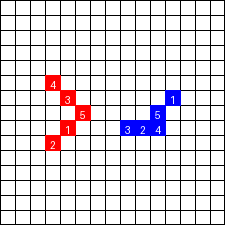

In [64]:
test_agent.make_gif(
    gif_path="message_a2c_test.gif",
    max_steps=200,
    greedy=False,
    fps=8
)
from IPython.display import Image, display
display(Image(filename="message_a2c_test.gif"))